In [2]:
import datetime 
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt 
import matplotlib.cm as cmx
import seaborn as sns
from sklearn.pipeline import make_pipeline, Pipeline  # diff twixt make_pipeline()/Pipeline(): https://stackoverflow.com/a/40708448
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

from githubanalysis.analysis.ML_pipeline import ML_Pipeline_Decision_Tree, main
from githubanalysis.analysis.ML_tuning_RF import main as tune_RF
#from githubanalysis.processing.predict_persona_MRC import persona_tester as persona_tester_script, makeRSE_persona_ranges as makeRSE_persona_ranges_script

current_date_info = datetime.datetime.now().strftime(
            "%Y-%m-%d"
        )
print(current_date_info)

2026-02-11


In [177]:
# RF RESULTS
RF_models = {
    "model": ["RF", "RF", "RF", "RF", "RF", "RF", "RF", "RF", "RF"], 
    "tuned": [ "untuned", "RandomizedSearchCV", "GridSearchCV", "HalvingGridSearchCV", "HalvingGridSearchCV","GridSearchCV", "RandomizedSearchCV", "HalvingGridSearchCV", "RandomizedSearchCV",], 
    "date_run": ["2025-10-08", "2026-02-05", "2026-02-11", "2026-02-11", "2026-02-12", "2026-02-25", "2026-02-25", "2026-02-12", "2026-02-20",],
    "run_ID":[None, None, 41188, 41752, 41770, 68459, 68434, 42121, 62044,], 
    "N_Obs":[115174, 50000, 50000, 10000, 50000, 10000, 50000, 50000, 10000,],
    "N_iterations": [ 1, 250, 25, 10, 25, 10, 25, 250, 10,],
    "paramsearchtime":[ np.nan,   5098.38629, 61396.10, 948.78681, 1005.87978, 22195.17636, 1412.80960, 1100.89896, 18.11820,],
    "traintime": [8.79, 0.95752, 0.66, 0.14014, 0.27435, 0.12713, 0.22870, 0.45034, 0.17620,], 
    "testtime": [ 0.18, 0.09436, 0.03, 0.015777, 0.01081, 0.01001, 0.01065, 0.024963, 0.01351,], 
    "accuracy": [0.99319, 0.97696 , 0.99248, 0.99080, 0.99112, 0.99240, 0.97256, 0.99112, 0.95480,], 
    "F1": [0.92451, 0.54668, 0.87171, 0.91070, 0.84223,  0.85858, 0.41432, 0.85648, 0.23451,], 
    "ROC_AUC_ovo": [0.99981, 0.89775, 0.99095, 0.98881, 0.98902, 0.98425, 0.88490, 0.98659, 0.77467,], # OVO (typically lower). Not ovr.
}
RF_models_df = pd.DataFrame(data=RF_models)
RF_models_df#.sort_values(["tuned", "N_Obs", "N_iterations"])


,model,tuned,date_run,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,accuracy,F1,ROC_AUC_ovo
0,RF,untuned,2025-10-08,NaN,115174,1,NaN,8.79000,0.180000,0.99319,0.92451,0.99981
1,RF,RandomizedSearchCV,2026-02-05,NaN,50000,250,5098.38629,0.95752,0.094360,0.97696,0.54668,0.89775
2,RF,GridSearchCV,2026-02-11,41188.0,50000,25,61396.10000,0.66000,0.030000,0.99248,0.87171,0.99095
3,RF,HalvingGridSearchCV,2026-02-11,41752.0,10000,10,948.78681,0.14014,0.015777,0.99080,0.91070,0.98881
4,RF,HalvingGridSearchCV,2026-02-12,41770.0,50000,25,1005.87978,0.27435,0.010810,0.99112,0.84223,0.98902
5,RF,GridSearchCV,2026-02-25,68459.0,10000,10,22195.17636,0.12713,0.010010,0.99240,0.85858,0.98425
6,RF,RandomizedSearchCV,2026-02-25,68434.0,50000,25,1412.80960,0.22870,0.010650,0.97256,0.41432,0.88490
7,RF,HalvingGridSearchCV,2026-02-12,42121.0,50000,250,1100.89896,0.45034,0.024963,0.99112,0.85648,0.98659
8,RF,RandomizedSearchCV,2026-02-20,62044.0,10000,10,18.11820,0.17620,0.013510,0.95480,0.23451,0.77467


In [178]:
# HGBT RESULTS
HGBT_models = {    
    "model": ["HGBT", "HGBT", "HGBT", "HGBT", "HGBT", "HGBT", "HGBT"], 
    "tuned": ["RandomizedSearchCV", "RandomizedSearchCV", "RandomizedSearchCV", "HalvingGridSearchCV", "HalvingGridSearchCV", "HalvingGridSearchCV", "untuned"], 
    "date_run": ["2026-02-24", "2026-02-25", "2026-02-25", "2026-02-25", "2026-02-25", "2026-02-25", "2025-10-08"],
    "run_ID":[66167, 66168, 68280, 68899, 70142, 70323, None, ], 
    "N_Obs":[10000, 50000, 50000, 10000, 50000, 50000, 115174],
    "N_iterations": [10, 250, 25, 10, 25, 250, 1],
    "paramsearchtime":[51.67409, 4744.27660, 643.19476, 125.08463, 198.79891, 200.31403, None,],
    "traintime": [1.28640, 4.29427, 13.98118, 1.16298, 1.45029, 1.99389, None,], 
    "testtime": [0.01837, 0.10087,  0.13504, 0.013438, 0.03938, 0.05852, None, ], 
    "accuracy": [0.99280, 0.99176, 0.99240, 0.99040, 0.99184, 0.99104, None ], 
    "F1": [0.74546, 0.86947, 0.87823, 0.72967, 0.85630, 0.83710, None, ], 
    "ROC_AUC_ovo": [0.98669, 0.98632, 0.98607, 0.84906, 0.97126, 0.98492, None, ], # OVO (typically lower). Not ovr.
}
HGBT_models_df = pd.DataFrame(data=HGBT_models)
HGBT_models_df.sort_values(["tuned", "N_Obs", "N_iterations"])

,model,tuned,date_run,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,accuracy,F1,ROC_AUC_ovo
3,HGBT,HalvingGridSearchCV,2026-02-25,68899.0,10000,10,125.08463,1.16298,0.013438,0.99040,0.72967,0.84906
4,HGBT,HalvingGridSearchCV,2026-02-25,70142.0,50000,25,198.79891,1.45029,0.039380,0.99184,0.85630,0.97126
5,HGBT,HalvingGridSearchCV,2026-02-25,70323.0,50000,250,200.31403,1.99389,0.058520,0.99104,0.83710,0.98492
0,HGBT,RandomizedSearchCV,2026-02-24,66167.0,10000,10,51.67409,1.28640,0.018370,0.99280,0.74546,0.98669
2,HGBT,RandomizedSearchCV,2026-02-25,68280.0,50000,25,643.19476,13.98118,0.135040,0.99240,0.87823,0.98607
1,HGBT,RandomizedSearchCV,2026-02-25,66168.0,50000,250,4744.27660,4.29427,0.100870,0.99176,0.86947,0.98632
6,HGBT,untuned,2025-10-08,NaN,115174,1,NaN,NaN,NaN,NaN,NaN,NaN


In [179]:
# GBT RESULTS
GBT_models = {    
    "model": ["GBT",], 
    "tuned": ["untuned"], 
    "date_run": ["2025-10-08"],
    "run_ID": [None],
    "N_Obs": [115174],
    "N_iterations": [1],
    "paramsearchtime":[None],
    "traintime": [None], 
    "testtime": [None],
    "accuracy": [None],
    "F1": [None],
    "ROC_AUC_ovo": [None], # OVO (typically lower). Not ovr.
}
GBT_models_df = pd.DataFrame(data=GBT_models)
GBT_models_df

,model,tuned,date_run,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,accuracy,F1,ROC_AUC_ovo
0,GBT,untuned,2025-10-08,None,115174,1,None,None,None,None,None,None


In [180]:
# CLUSTERING ONLY
clustering_version = {    
    "model": ["clustering",], 
    "tuned": [None],
    "date_run": ["2025-05-12", ],
    "run_ID":[None,], 
    "N_Obs":[115174,],
    "N_iterations": [np.nan,],
    "paramsearchtime":[np.nan, ],
    "traintime": [np.nan, ], 
    "testtime": [np.nan,], 
    "totalTTtime": [23531.53],
    "accuracy": [np.nan,], 
    "F1": [np.nan, ], 
    "ROC_AUC_ovo": [np.nan, ], # OVO (typically lower). Not ovr.
}
clustering_df = pd.DataFrame(data=clustering_version)
clustering_df

,model,tuned,date_run,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,totalTTtime,accuracy,F1,ROC_AUC_ovo
0,clustering,None,2025-05-12,None,115174,NaN,NaN,NaN,NaN,23531.53,NaN,NaN,NaN


In [181]:
# UNITE!
models_df = pd.concat([RF_models_df, HGBT_models_df, GBT_models_df])

models_df['totalTTtime'] =  models_df["traintime"] + models_df['testtime'] # in seconds
models_df.sort_values(by=["model", "tuned", "N_Obs", "N_iterations", "totalTTtime", "ROC_AUC_ovo"], ascending=[True, False, False, False, True, False])

/tmp/ipykernel_4424/3936768265.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  models_df = pd.concat([RF_models_df, HGBT_models_df, GBT_models_df])


,model,tuned,date_run,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,accuracy,F1,ROC_AUC_ovo,totalTTtime
0,GBT,untuned,2025-10-08,NaN,115174,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,HGBT,untuned,2025-10-08,NaN,115174,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HGBT,RandomizedSearchCV,2026-02-25,66168.0,50000,250,4744.27660,4.29427,0.100870,0.99176,0.86947,0.98632,4.395140
2,HGBT,RandomizedSearchCV,2026-02-25,68280.0,50000,25,643.19476,13.98118,0.135040,0.99240,0.87823,0.98607,14.116220
0,HGBT,RandomizedSearchCV,2026-02-24,66167.0,10000,10,51.67409,1.28640,0.018370,0.99280,0.74546,0.98669,1.304770
5,HGBT,HalvingGridSearchCV,2026-02-25,70323.0,50000,250,200.31403,1.99389,0.058520,0.99104,0.83710,0.98492,2.052410
4,HGBT,HalvingGridSearchCV,2026-02-25,70142.0,50000,25,198.79891,1.45029,0.039380,0.99184,0.85630,0.97126,1.489670
3,HGBT,HalvingGridSearchCV,2026-02-25,68899.0,10000,10,125.08463,1.16298,0.013438,0.99040,0.72967,0.84906,1.176418
0,RF,untuned,2025-10-08,NaN,115174,1,NaN,8.79000,0.180000,0.99319,0.92451,0.99981,8.970000
1,RF,RandomizedSearchCV,2026-02-05,NaN,50000,250,5098.38629,0.95752,0.094360,0.97696,0.54668,0.89775,1.051880


In [182]:
# ADD CLUSTERING
all_methods = pd.concat([clustering_df, models_df])
all_methods

/tmp/ipykernel_4424/2220814061.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_methods = pd.concat([clustering_df, models_df])


,model,tuned,date_run,run_ID,N_Obs,N_iterations,paramsearchtime,traintime,testtime,totalTTtime,accuracy,F1,ROC_AUC_ovo
0,clustering,None,2025-05-12,NaN,115174,NaN,NaN,NaN,NaN,23531.530000,NaN,NaN,NaN
0,RF,untuned,2025-10-08,NaN,115174,1.0,NaN,8.79000,0.180000,8.970000,0.99319,0.92451,0.99981
1,RF,RandomizedSearchCV,2026-02-05,NaN,50000,250.0,5098.38629,0.95752,0.094360,1.051880,0.97696,0.54668,0.89775
2,RF,GridSearchCV,2026-02-11,41188.0,50000,25.0,61396.10000,0.66000,0.030000,0.690000,0.99248,0.87171,0.99095
3,RF,HalvingGridSearchCV,2026-02-11,41752.0,10000,10.0,948.78681,0.14014,0.015777,0.155917,0.99080,0.91070,0.98881
4,RF,HalvingGridSearchCV,2026-02-12,41770.0,50000,25.0,1005.87978,0.27435,0.010810,0.285160,0.99112,0.84223,0.98902
5,RF,GridSearchCV,2026-02-25,68459.0,10000,10.0,22195.17636,0.12713,0.010010,0.137140,0.99240,0.85858,0.98425
6,RF,RandomizedSearchCV,2026-02-25,68434.0,50000,25.0,1412.80960,0.22870,0.010650,0.239350,0.97256,0.41432,0.88490
7,RF,HalvingGridSearchCV,2026-02-12,42121.0,50000,250.0,1100.89896,0.45034,0.024963,0.475303,0.99112,0.85648,0.98659
8,RF,RandomizedSearchCV,2026-02-20,62044.0,10000,10.0,18.11820,0.17620,0.013510,0.189710,0.95480,0.23451,0.77467


In [133]:
models_50k_250it = models_df.query("N_Obs == 50000")
models_50k_250it.sort_values(by=["tuned","model", "N_iterations", "ROC_AUC_ovo", "totalTTtime", ], ascending=[True, True, False, False, True])

,model,tuned,date_run,N_Obs,N_iterations,paramsearchtime,traintime,testtime,accuracy,F1,ROC_AUC_ovo,totalTTtime
2,RF,GridSearchCV,2026-02-11,50000.0,25.0,61396.10000,0.66000,0.03000,0.99248,0.87171,0.99095,0.69000
5,HGBT,HalvingGridSearchCV,2026-02-25,50000.0,250.0,200.31403,1.99389,0.05852,0.99104,0.83710,0.98492,2.05241
4,HGBT,HalvingGridSearchCV,2026-02-25,50000.0,25.0,198.79891,1.45029,0.03938,0.99184,0.85630,0.97126,1.48967
4,RF,HalvingGridSearchCV,2026-02-25,50000.0,25.0,1005.88000,0.27435,0.01081,0.99112,0.84223,0.98902,0.28516
1,HGBT,RandomizedSearchCV,2026-02-25,50000.0,250.0,4744.28000,4.29427,0.10087,0.99176,0.86947,0.98632,4.39514
2,HGBT,RandomizedSearchCV,2026-02-25,50000.0,25.0,643.19476,13.98118,0.13504,0.99240,0.87823,0.98607,14.11622
1,RF,RandomizedSearchCV,2026-02-05,50000.0,250.0,5098.39000,0.96000,0.09000,0.97696,0.54668,0.89775,1.05000
6,RF,RandomizedSearchCV,2026-02-25,50000.0,25.0,1412.80960,0.22870,0.01065,0.97256,0.41432,0.88490,0.23935


50k Obs, 250 it, 


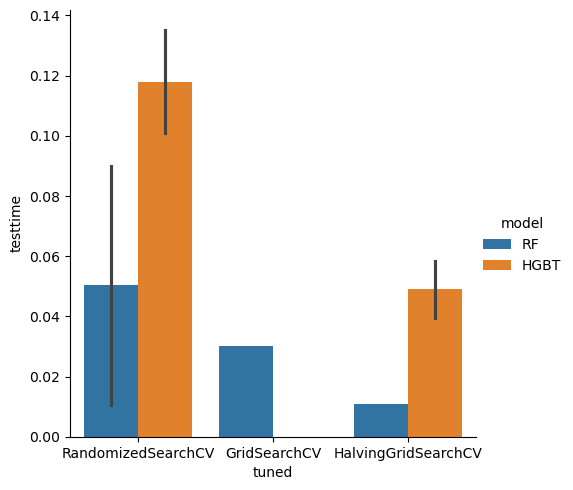

In [134]:
sns.catplot(data=models_50k_250it, x="tuned", y="testtime", hue="model", kind="bar")
print("50k Obs, 250 it, ")

Text(0.5, 1.0, 'Set2 Dataset First Clustering Runtime: % Set2 Repos vs Runtime')

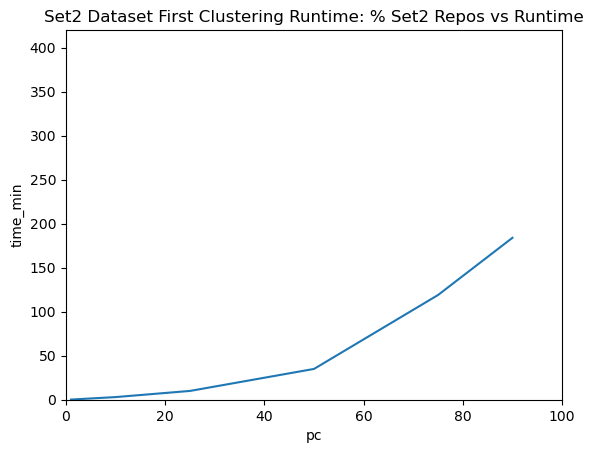

In [39]:
set2runtimes = {"pc": [1, 10, 25, 50, 75, 90,  100], "time_min": [0.2, 3, 10, 35, 119, 184, None,]}
set2runtimes_df = pd.DataFrame(data=set2runtimes)
set2runtimes_df

ax = sns.lineplot(data=set2runtimes_df, x="pc", y="time_min", )
ax.set(xlim=(0, 100)) # 100 pc of dataset max
ax.set(ylim=(0, 420)) # Over 7 hours max
ax.set_title("""Set2 Dataset First Clustering Runtime: % Set2 Repos vs Runtime""")

Issues: 

admin/#229 
admin/#230

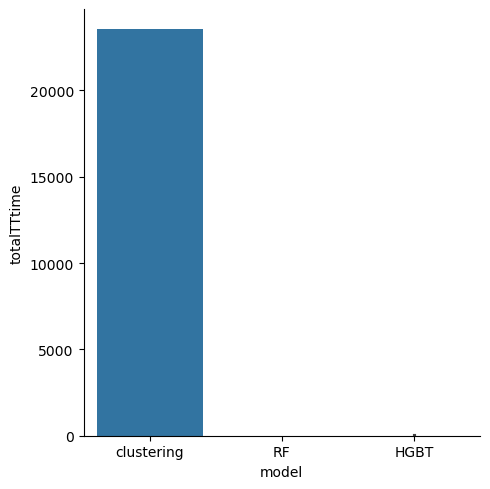

In [66]:
sns.catplot(data=models_df, x="model", y="totalTTtime", hue="model", kind="bar", log_scale=False,) 
# this is unhelpful D:
# could maybe add the values on above the bars, so that there's SOMETHING for RF?

In [ ]:
models_df.iloc[1:,:]

total run time (excl hyper-param search) values for RF


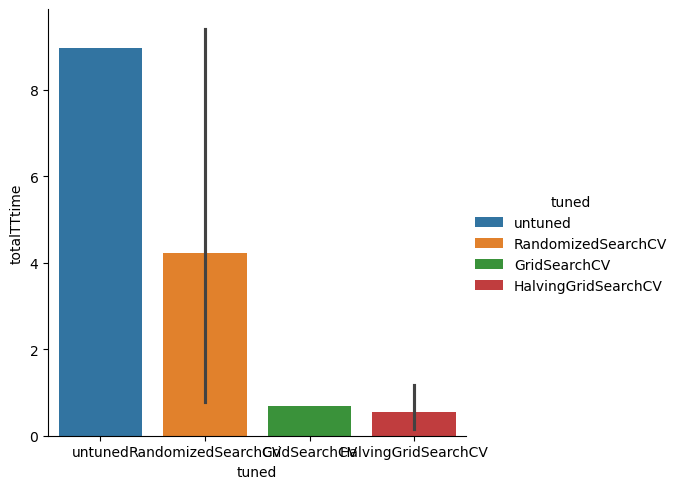

In [88]:
sns.catplot(data=models_df, x="tuned", y="totalTTtime", hue="tuned", kind="bar", log_scale=False) 
print("total run time (excl hyper-param search) values for RF")

Accuracy values for RF


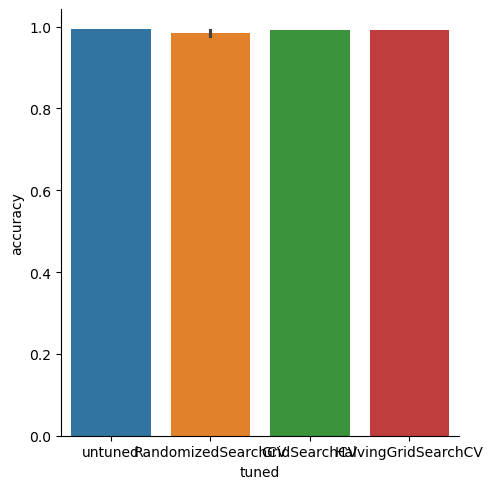

In [89]:
sns.catplot(data=models_df.iloc[1:,:], x="tuned", y="accuracy", hue="tuned", kind="bar", log_scale=False,) 
print("Accuracy values for RF")

F1 values for RF


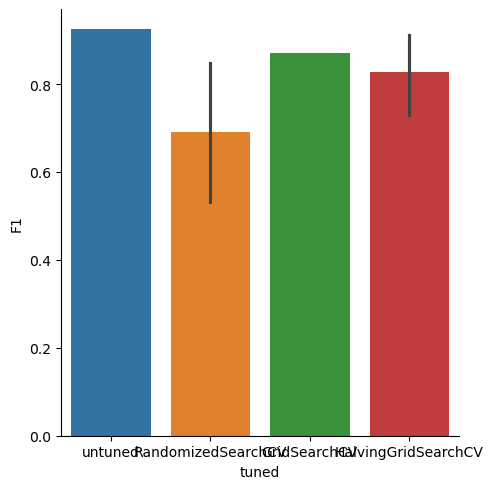

In [90]:
sns.catplot(data=models_df.iloc[1:,:], x="tuned", y="F1", hue="tuned", kind="bar", log_scale=False,) 
print("F1 values for RF")

ValueError: cannot reindex on an axis with duplicate labels

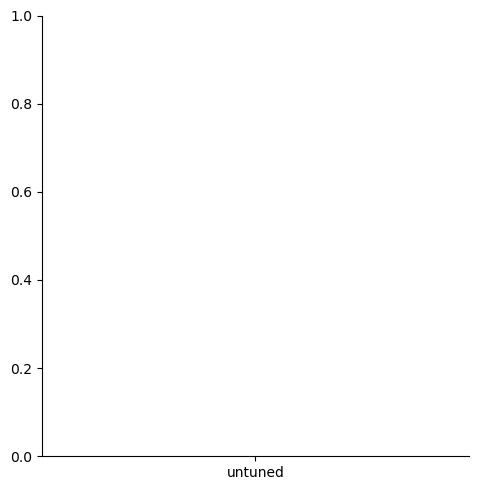

In [129]:
#sns.catplot(data=models_df, x="tuned", y="ROC_AUC_ovo", hue="model", kind="bar", log_scale=False,) 
#print("ROC_AUC_ovo for RF")

ROC_AUC for RF, 50k Obs, 250 Iterations


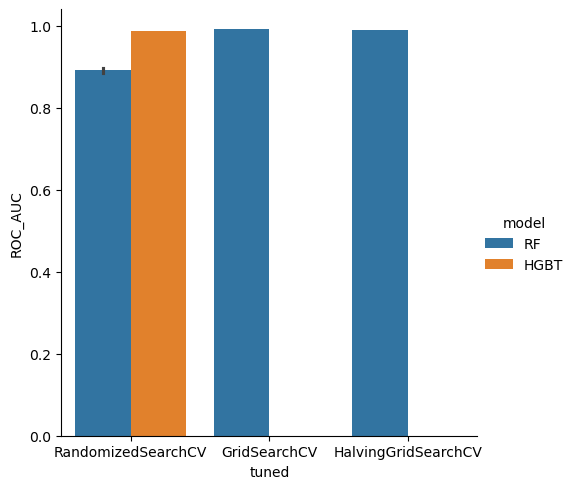

In [92]:
sns.catplot(data=models_50k_250it, x="tuned", y="ROC_AUC_ovo", hue="model", kind="bar", log_scale=False,) 
print("ROC_AUC for RF, 50k Obs, 250 Iterations")

N of Observations used for test/train split for RF


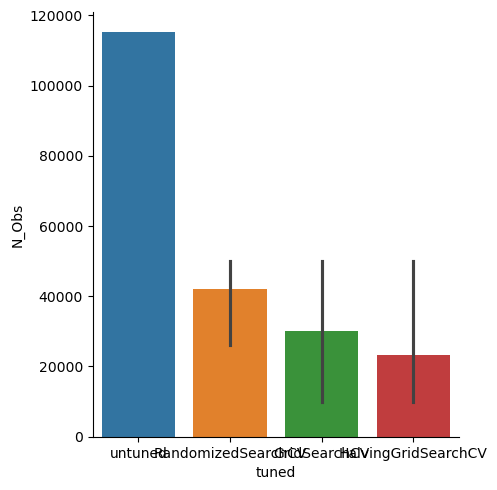

In [93]:
#sns.catplot(data=models_df, x="tuned", y="N_Obs", hue="tuned", kind="bar", log_scale=False,) 
#print("N of Observations used for test/train split for RF")

In [16]:
pd.read_csv("../../data/RF_paramsearch_N2500_2026-02-14.csv")

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,param_criterion,param_max_depth,param_max_features,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0,70,0.154573,0.017711,0.025764,0.006611,0.000,gini,10.0,2.0,...,0.480912,0.268130,7669,0.486239,0.481481,0.486239,0.320988,0.490909,0.453171,0.066159
1,0,70,0.232230,0.020514,0.028423,0.003365,0.000,gini,10.0,2.0,...,0.480912,0.268130,7669,0.486239,0.481481,0.486239,0.320988,0.490909,0.453171,0.066159
2,0,70,0.293513,0.023526,0.034928,0.004028,0.000,gini,10.0,2.0,...,0.480912,0.268130,7669,0.486239,0.481481,0.486239,0.320988,0.490909,0.453171,0.066159
3,0,70,0.368439,0.018571,0.034851,0.007463,0.000,gini,10.0,2.0,...,0.480912,0.268130,7669,0.486239,0.481481,0.486239,0.320988,0.490909,0.453171,0.066159
4,0,70,0.170279,0.009303,0.019161,0.001824,0.000,gini,10.0,2.0,...,0.480912,0.268130,7669,0.486239,0.481481,0.486239,0.320988,0.490909,0.453171,0.066159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13763,4,5670,0.538468,0.028411,0.076480,0.019607,0.000,gini,10.0,NaN,...,0.697009,0.036474,201,0.920617,0.882715,0.862821,0.920622,0.880319,0.893419,0.023247
13764,4,5670,0.569395,0.033803,0.077356,0.033437,0.005,log_loss,10.0,NaN,...,0.700144,0.044145,178,0.734745,0.782456,0.759039,0.779582,0.786267,0.768418,0.019298
13765,4,5670,0.616945,0.024361,0.073280,0.026640,0.000,log_loss,35.0,4.0,...,0.710852,0.045961,131,0.939486,0.928279,0.807408,0.808952,0.881481,0.873121,0.056485
13766,4,5670,0.606215,0.053452,0.059882,0.020057,0.005,log_loss,35.0,NaN,...,0.725753,0.038842,93,0.755484,0.748198,0.754470,0.787138,0.783300,0.765718,0.016163


In [17]:
pd.read_csv("../../data/test_prediction_data_N2500_2026-02-14.csv")

,Test true,Test predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,5,5
...,...,...
2495,1,1
2496,1,1
2497,1,1
2498,1,1


In [ ]:
##### THIS IS THE SCRIPT CODE BEING RUN; DECISION TREE SHENANIGANS BELOW:

In [ ]:
#from githubanalysis.analysis.baby_ML_pipeline import ML_Pipeline_Decision_Tree, main
main(
    dataset_name="ML",
    in_notebook=True,
    exists_ok=True,
    logger=None,
    datafile="sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
    small_vers=True,
    small_N_appx=50,
    train_pc=0.75,
    test_pc=0.25,
    shuffle_state=True,
    stratify_state=True, # ensuring all personas present in test and training in ~natural ratio
)

[Pipeline] ............... (step 1 of 1) Processing clf, total=   0.4s
attempted to save out to : ../../images/analysis_run_ML_2026-02-02/decision_tree_initial.pdf


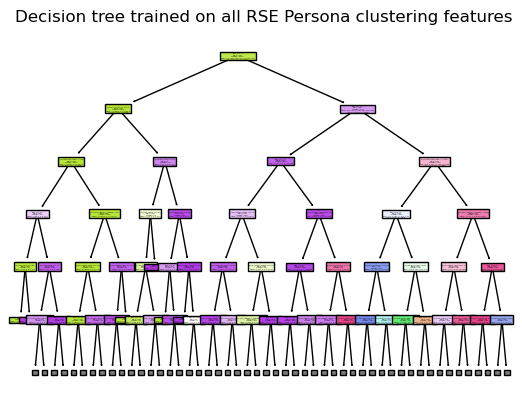

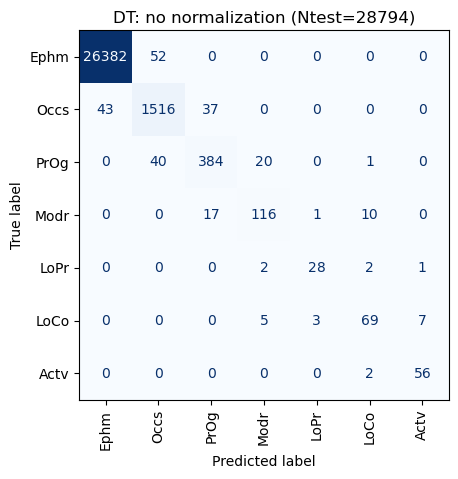

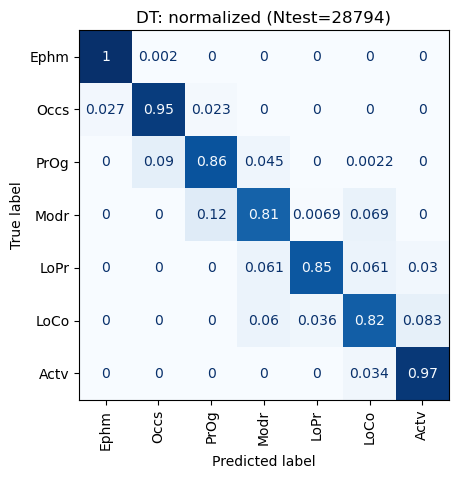


            For decision_tree model trained on: 

            datafile: ../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv 

            training-set size: N=86380 

            and evaluated using test-set size: N=28794 repo-individuals 

            using N=10 features 
 
            at 2026-02-02 

            TRAIN (fit) TIME: 0.3631420135498047 seconds 

            TEST (predict) TIME: 0.005074024200439453 seconds 

            with parameters: {'memory': None, 'steps': [('clf', DecisionTreeClassifier(random_state=42))], 'verbose': True}
            
Accuracy: 0.99156 (percent of correctly classified samples)
Non-Normalised Accuracy: 28551 (number of correctly classified samples)
Balanced Accuracy: 0.89312 (the average of recall obtained on each class)
F1 Score: 0.88909 (harmonic mean of the precision and recall, both equally weighted)
Precision: 0.88578 (Ratio of correctly predicted positive classes to total of positive predictions)
Recall: 0.89312 (Ra

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    8.2s finished


[Pipeline] ............... (step 1 of 1) Processing clf, total=   8.8s


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


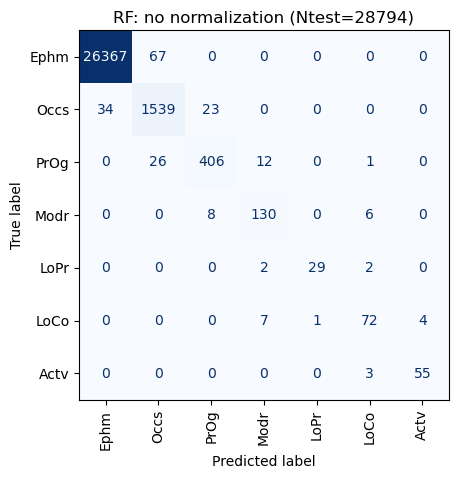

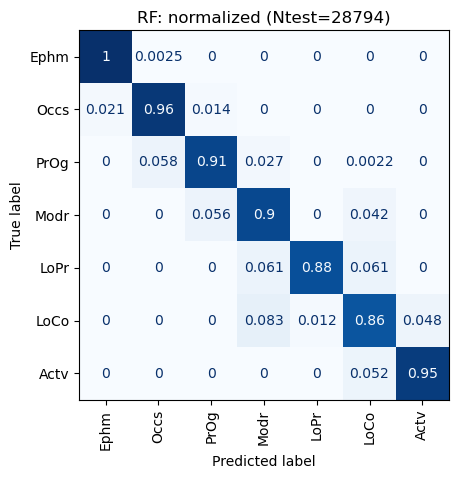


            For random_forest model trained on: 

            datafile: ../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv 

            training-set size: N=86380 

            and evaluated using test-set size: N=28794 repo-individuals 

            using N=10 features 
 
            with N=100 trees in forest  

            at 2026-02-02 
 
            TRAIN (fit) TIME: 8.78955888748169 seconds 

            TEST (predict) TIME: 0.18402099609375 seconds 

            with parameters: {'memory': None, 'steps': [('clf', RandomForestClassifier(max_features=3, oob_score=True, random_state=42,
                       verbose=1))], 'verbose': True}
        
Accuracy: 0.99319 (percent of correctly classified samples)
Non-Normalised Accuracy: 28598 (number of correctly classified samples)
Balanced Accuracy: 0.92301 (the average of recall obtained on each class)
F1 Score: 0.92451 (harmonic mean of the precision and recall, both equally weighted)
Precision: 0.92682 (

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


Area Under the Receiver Operating Characteristic Curve (ROC AUC): 0.99981
Out of Bag Error: 0.00644
Classification Report: 
                         precision    recall  f1-score   support

    Active Contributor      0.932     0.948     0.940        58
 Ephemeral Contributor      0.999     0.997     0.998     26434
     Low-Coding Closer      0.857     0.857     0.857        84
    Low-Process Closer      0.967     0.879     0.921        33
  Moderate Contributor      0.861     0.903     0.881       144
Occasional Contributor      0.943     0.964     0.954      1596
     Project Organiser      0.929     0.912     0.921       445

              accuracy                          0.993     28794
             macro avg      0.927     0.923     0.925     28794
          weighted avg      0.993     0.993     0.993     28794

Binning 0.007 GB of training data: 0.096 s
Fitting gradient boosted rounds:
[1/100] 7 trees, 482 leaves (68 on avg), max depth = 16, in 0.086s
[2/100] 7 trees, 1854 lea

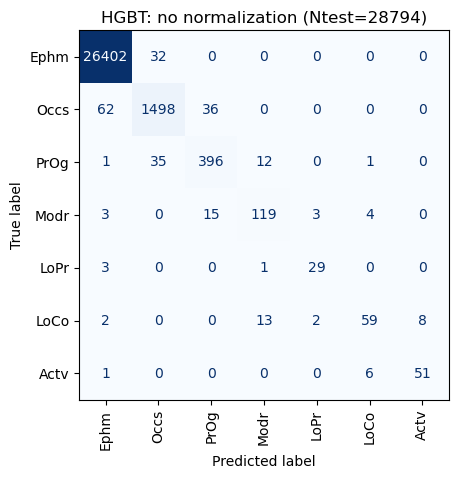

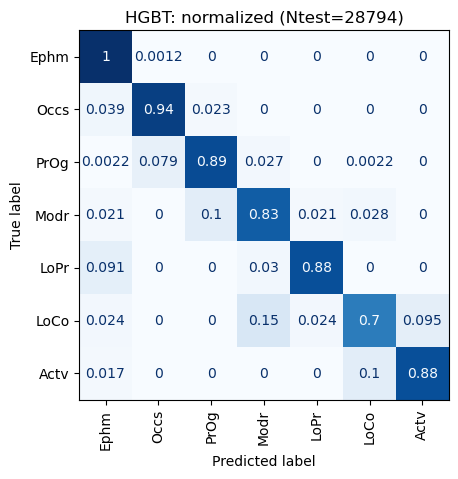


            For hist_gradient_boosting model trained on: 

            datafile: ../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv 

            training-set size: N=86380 

            and evaluated using test-set size: N=28794 repo-individuals 

            using N=10 features 
 
            at 2026-02-02 

            TRAIN (fit) TIME: 29.276313066482544 seconds 

            TEST (predict) TIME: 0.4810316562652588 seconds 

            with parameters: {'memory': None, 'steps': [('clf', HistGradientBoostingClassifier(early_stopping=False, l2_regularization=0,
                               learning_rate=0.01, max_leaf_nodes=None,
                               random_state=42, verbose=1))], 'verbose': True}
            
Accuracy: 0.99166 (percent of correctly classified samples)
Non-Normalised Accuracy: 28554 (number of correctly classified samples)
Balanced Accuracy: 0.87345 (the average of recall obtained on each class)
F1 Score: 0.88014 (harmonic mean

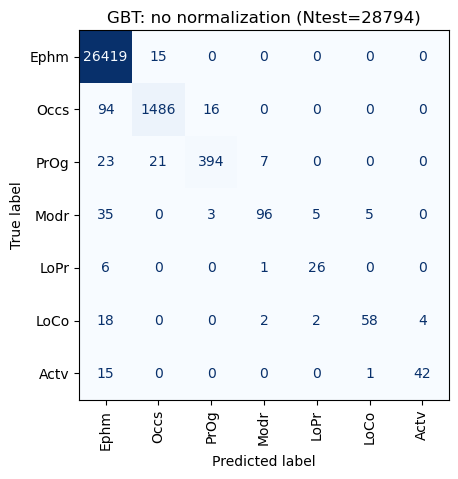

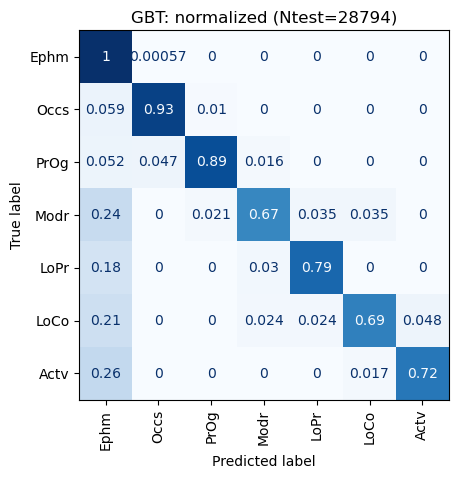


            For gradient_boosting model trained on: 

            datafile: ../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv 

            training-set size: N=86380 

            and evaluated using test-set size: N=28794 repo-individuals 

            using N=10 features 
 
            at 2026-02-02 

            TRAIN (fit) TIME: 143.66232228279114 seconds 

            TEST (predict) TIME: 0.6406552791595459 seconds 

            with parameters: {'memory': None, 'steps': [('clf', GradientBoostingClassifier(learning_rate=0.01, max_depth=None, max_features=3,
                           random_state=42))], 'verbose': True}
            
Accuracy: 0.99052 (percent of correctly classified samples)
Non-Normalised Accuracy: 28521 (number of correctly classified samples)
Balanced Accuracy: 0.81215 (the average of recall obtained on each class)
F1 Score: 0.85929 (harmonic mean of the precision and recall, both equally weighted)
Precision: 0.91943 (Ratio of corre

In [3]:
#from githubanalysis.analysis.baby_ML_pipeline import ML_Pipeline_Decision_Tree, main
main(
    dataset_name="ML",
    in_notebook=True,
    exists_ok=True,
    logger=None,
    datafile="sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
    small_vers=False,
    small_N_appx=None,
    train_pc=0.75,
    test_pc=0.25,
    shuffle_state=True,
    stratify_state=True, # ensuring all personas present in test and training in ~natural ratio
)

In [4]:
from datetime import datetime

#FMT = '%Y-%m-%d %H:%M:%S.%f'
init_start = "2025-05-12 23:48:29,432"
init_end= "2025-05-13 02:50:10,882"
        
init_time = datetime.fromisoformat(init_end.replace(',', '.')) - datetime.fromisoformat(init_start.replace(',', '.'))
init_time

cl0_start = "2025-05-13 12:54:19,291"
cl0_end = "2025-05-13 12:54:24,940"
cl0_time = datetime.fromisoformat(cl0_end.replace(',', '.')) - datetime.fromisoformat(cl0_start.replace(',', '.'))

cl1_start = "2025-05-13 12:53:55,309"
cl1_end = "2025-05-13 12:53:59,770"
cl1_time = datetime.fromisoformat(cl1_end.replace(',', '.')) - datetime.fromisoformat(cl1_start.replace(',', '.'))

cl2_start = "2025-05-13 07:30:19,998"
cl2_end = "2025-05-13 11:00:39,965"
cl2_time = datetime.fromisoformat(cl2_end.replace(',', '.')) - datetime.fromisoformat(cl2_start.replace(',', '.'))

overall_time = init_time + cl0_time + cl1_time + cl2_time
print(f"{overall_time.total_seconds()} seconds total")

print(f"{overall_time.total_seconds()/60} minutes total")
print(f"{overall_time.total_seconds()/60/60} hours total")


print(f"8.97s is {overall_time.total_seconds()/8.97} times faster than clustering...")

23531.527 seconds total
392.19211666666666 minutes total
6.536535277777777 hours total
8.97s is 2623.3586399108135 times faster than clustering...


In [5]:
        self.y_pred = self.pipe.predict(X_test)
        self.y_true = y_test

        # savefig kwargs
        saveout_args = dict(
            dpi=400,
            format="pdf",
            bbox_inches="tight",
        )

        # Plot non-normalized confusion matrix
        titles_options = [
            (
                f"{self.model_type} CM, no normalization (N={self.X_test_size[0]})",
                None,
            ),
            (
                f"{self.model_type} normalized CM (N={self.X_test_size[0]})",
                "true",
            ),  # normalise on True value pcs
        ]

        persona_order = [
            "Ephemeral Contributor",
            "Occasional Contributor",
            "Project Organiser",
            "Moderate Contributor",
            "Low-Process Closer",
            "Low-Coding Closer",
            "Active Contributor",
        ]

        for title, normalize in titles_options:
            disp = ConfusionMatrixDisplay.from_predictions(
                self.le.inverse_transform(self.y_true),  # y_true
                self.le.inverse_transform(self.y_pred),  # y_pred
                labels=persona_order,  # personas listed in increasing MRC order
                sample_weight=None,
                normalize=normalize,  # 'all': total N samples; 'pred': over predictions; 'true': over true; None: default
                display_labels=None,
                include_values=True,
                xticks_rotation="vertical",
                values_format=None,
                cmap=cmx.Blues,
                ax=None,
                colorbar=False,
                im_kw=None,
                text_kw=None,
            )
            disp.ax_.set_title(title)
            saveout_name = Path(
                self.image_write_location,
                f"{self.model_type}_confusion_matrix_normalise{normalize}_N{self.X_test_size[0]}_{self.current_date_info}.pdf",
            )
            plt.savefig(
                saveout_name,
                **saveout_args,
            )
            plt.show()


NameError: name 'self' is not defined

In [ ]:
# DECISION-TREE
# 150k dataset of repo-individuals (Set1/45pc)

# run as single function: 
main(
    dataset_name="ML",
    in_notebook=True,
    exists_ok=True,
    logger=None,
    datafile="../../data/sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
    small_vers=False,
    small_N_appx=None,
    train_pc=0.75,
    test_pc=0.25,
    shuffle_state=True,
    stratify_state=True, # ensuring all personas present in test and training in ~natural ratio
)

In [ ]:
# DECISION-TREE
# small (per-persona-sampled) dataset as 'whole sample', aiming for ~50ish records 

#proto-code for pipeline, pulled into main() run as single function: 

ml_pipeline_dt = ML_pipeline_decision_tree(dataset_name="ML", in_notebook=True, exists_ok=True, logger=None)

# create a pipeline object
pipe = Pipeline(steps=[ # diff twixt make_pipeline()/Pipeline(): https://stackoverflow.com/a/40708448
    #('le', LabelEncoder()),
    ('clf', DecisionTreeClassifier()),
], 
    memory=None, 
    #transform_input=None, # I maybe don't have the updated package version for this (1.6?)
    verbose=True,
)
print(pipe.get_params())

# load the dataset and split it into train and test sets
# read in dataset
datafile = Path(
    ml_pipeline_dt.data_location,
    "sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
)
# small (per-persona-sampled) dataset as 'whole sample', aiming for ~50ish records 
classified_df = ml_pipeline_dt.get_data(data_file=datafile, small_vers=True, small_N_appx=50) # 50ish REPO-INDIVIDS ONLY!
RSE_info = ml_pipeline_dt.create_sklearn_format_data(classified_df=classified_df)

# set X (data, no colnames, no personas), y (personas only)
X, y = RSE_info["data"], RSE_info["target"]

# create testing/training dataset
X_train, X_test, y_train, y_test = train_test_split(
                X,
                y,
                #test_size, #=test_pc,  # by (sklearn) default if int: N of samples; if float: proportion of sample; if None and train_size=None also, it uses 25%
                #train_size, #=train_pc,  # by (sklearn) default if int: N of samples; if float: proportion of sample; if None and train_size=None also, it uses 75%
                random_state=42,
                shuffle=True, #shuffle_state,  # True by (sklearn) default
                stratify=RSE_info[
                    "target"
                ],  # same as y; None by (sklearn) default
            )

# fit the whole pipeline
##########

pipe.fit(X_train, y_train)

# plot the decision tree
tree.plot_tree(
    pipe.named_steps['clf'], # use fitted pipe obj created by 'decision_tree step'
    max_depth=5, 
    filled=True,
    feature_names=RSE_info["feature_names"],
    class_names=RSE_info["target_names"],
)

pipe.predict(X_test)
#pipe.le.transform(y_test)

# savefig kwargs
saveout_args = dict(
    dpi=400,
    format="pdf",
    bbox_inches="tight",
)
dataset_size = len(X_test)

# Plot non-normalized confusion matrix
titles_options = [
    (
        f"confusion matrix, no normalization (N={dataset_size})",
        None,
    ),
    (
        f"normalized confusion matrix (N={dataset_size})",
        "true",
    ),  # normalise on True value pcs
]


for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_predictions(
        #y_pred = pipe.predict(X_test),    
        y_pred = ml_pipeline_dt.le.inverse_transform(pipe.predict(X_test)), 
        #y_true= y_test,  
        #self.le.inverse_transform(y_true),  # y_true
        y_true = ml_pipeline_dt.le.inverse_transform(y_test),  # y_pred
        labels=ml_pipeline_dt.le.inverse_transform(pipe.named_steps['clf'].classes_),
        sample_weight=None,
        normalize=normalize,  # 'all': total N samples; 'pred': over predictions; 'true': over true; None: default
        display_labels=None,
        include_values=True,
        xticks_rotation="vertical",
        values_format=None,
        cmap=cmx.Blues,
        ax=None,
        colorbar=False,
        im_kw=None,
        text_kw=None,
    )
    disp.ax_.set_title(title)
#     saveout_name = Path(
#         self.image_write_location,
#         f"confusion_matrix_MRC_tinytestset_normalise{normalize}_{self.current_date_info}.pdf",
#     )
#     plt.savefig(
#         saveout_name,
#         **saveout_args,
#     )
    plt.show()

In [ ]:
# STEP BY STEP BELOW:
# DECISION-TREE

In [ ]:
from githubanalysis.analysis.baby_ML_pipeline import ML_pipeline_decision_tree, main

In [ ]:
ml_pipeline_dt = ML_pipeline_decision_tree(dataset_name="ML", in_notebook=True, exists_ok=True, logger=None)

In [ ]:
from pathlib import Path
# read in dataset
datafile = Path(
    ml_pipeline_dt.data_location,
    "sample_45pc_all_subclusters_named_personas_dataset_2025-09-16.csv",
)

# small (per-persona-sampled) dataset as 'whole sample', aiming for ~20ish records 
classified_df = ml_pipeline_dt.get_data(data_file=datafile, small_vers=True, small_N_appx=20) 


In [ ]:
ml_pipeline_dt.create_sklearn_format_data(classified_df=classified_df)

In [ ]:
clf, X_train, X_test, y_train, y_test = ml_pipeline_dt.do_decision_tree()

In [ ]:
ml_pipeline_dt.plot_decision_tree(clf)

In [ ]:
ml_pipeline_dt.run_predictor(clf, X_test, y_test, classified_df)